In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration affichage
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

print("✅ Librairies importées avec succès !")

✅ Librairies importées avec succès !


In [3]:
# Chargement du fichier principal
df = pd.read_csv('../../data/data_churn.csv', low_memory=False)

# Chargement des dimensions
dim_category   = pd.read_excel('../../data/dim_CATEGORY.ACCOUNT.xlsx')
dim_closure    = pd.read_excel('../../data/dim_Closure_reason.xlsx')
dim_currency   = pd.read_excel('../../data/dim_CURRENCY.xlsx')
dim_dao        = pd.read_excel('../../data/dim_DAO.xlsx')
dim_industry   = pd.read_excel('../../data/dim_INDUSTRY.xlsx')
dim_sector     = pd.read_excel('../../data/dim_SECTOR.xlsx')
dim_target     = pd.read_excel('../../data/dim_TARGET.xlsx')
dim_transaction= pd.read_excel('../../data/dim_TRANSACTION.xlsx')

print(f"✅ Données chargées !")
print(f"📊 Fichier principal : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\n📁 Tables de dimensions :")
for name, d in [('dim_category', dim_category), ('dim_closure', dim_closure),
                ('dim_currency', dim_currency), ('dim_dao', dim_dao),
                ('dim_industry', dim_industry), ('dim_sector', dim_sector),
                ('dim_target', dim_target), ('dim_transaction', dim_transaction)]:
    print(f"   {name:20s} → {d.shape[0]} lignes × {d.shape[1]} colonnes")

✅ Données chargées !
📊 Fichier principal : 528,883 lignes × 34 colonnes

📁 Tables de dimensions :
   dim_category         → 50 lignes × 3 colonnes
   dim_closure          → 32 lignes × 2 colonnes
   dim_currency         → 22 lignes × 4 colonnes
   dim_dao              → 150 lignes × 4 colonnes
   dim_industry         → 663 lignes × 2 colonnes
   dim_sector           → 45 lignes × 2 colonnes
   dim_target           → 11 lignes × 2 colonnes
   dim_transaction      → 3038 lignes × 2 colonnes


In [4]:
# Aperçu des premières lignes
print("=== APERÇU DES DONNÉES ===")
display(df.head(3))

# Informations générales
print("\n=== TYPES DES COLONNES ===")
print(df.dtypes)

# Dimensions
print(f"\n=== FORME DU DATASET ===")
print(f"Lignes    : {df.shape[0]:,}")
print(f"Colonnes  : {df.shape[1]}")


=== APERÇU DES DONNÉES ===


,CUSTOMER_NO,ACCOUNT_NO,NATIONALITY,RESIDENCE,MARITAL_STATUS,CUST_OPENING_DATE,DATE_OF_BIRTH,NATURE_CLIENT,BRANCH,SCORE_KYC,COMPLETED_FILE,LAST_REVIEW_DATE,NEXT__REVIEW_DATE,ACCOUNT_STATUS,ACCT_OPENING_DATE,ACCOUNT_CATEGORY,ACCOUNT_TYPE_DESC,CURRENCY,ACCT_CLOSE_DATE,CLOSURE_REASON,ACCT_BALANCE,INDUSTRY,SALARY,PRODUCT_GROUP,PRODUCT_LINE,PRODUCT,ACCOUNTNATURE,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,PRODUCT_STATUS,PARTYCLASS,LOB
0,C318650,A0365322,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,YES,20250905.00,20290905.00,Closed,20190827.00,3023.00,Crédit acquisition logement TEGF6,TND,20260128.00,NaN,-10714.35,9000,2725.74,RT.CRD.IMMOBILERS,LENDING,RT.RT.CRD.IMMOBILERS.527,Crédit acquisition logement TEGF6,1251227.00,1290627.00,10954600.00,4.50,CURRENT,Retail,4
1,C318648,A0373555,TN,TN,M,20040930.00,1960.00,PPH,BR114,LR,YES,20250905.00,20290905.00,Closed,20260105.00,3611.00,DEPOTS A TERME,TND,20250630.00,NaN,0.00,9000,3300.54,BANK.PLACEMENT.NEG,DEPOSITS,BANK.CAT.NEG.SIM,DEPOTS A TERME,20260102.00,NaN,NaN,NaN,UNAUTH,Retail,4
2,C318650,A0348290,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,YES,20250905.00,20290905.00,Closed,20230612.00,3017.00,Crédit rénovation,TND,20260128.00,NaN,-113033.10,9000,2725.74,RT.CRD.IMMOBILERS,LENDING,RT.RT.CRD.IMMOBILERS.548,Crédit rénovation,1251227.00,1380527.00,113593077.00,4.50,CURRENT,Retail,4



=== TYPES DES COLONNES ===
CUSTOMER_NO           object
ACCOUNT_NO            object
NATIONALITY           object
RESIDENCE             object
MARITAL_STATUS        object
CUST_OPENING_DATE    float64
DATE_OF_BIRTH        float64
NATURE_CLIENT         object
BRANCH                object
SCORE_KYC             object
COMPLETED_FILE        object
LAST_REVIEW_DATE     float64
NEXT__REVIEW_DATE    float64
ACCOUNT_STATUS        object
ACCT_OPENING_DATE    float64
ACCOUNT_CATEGORY     float64
ACCOUNT_TYPE_DESC     object
CURRENCY              object
ACCT_CLOSE_DATE      float64
CLOSURE_REASON        object
ACCT_BALANCE         float64
INDUSTRY               int64
SALARY               float64
PRODUCT_GROUP         object
PRODUCT_LINE          object
PRODUCT               object
ACCOUNTNATURE         object
STARTDATE            float64
MATURITYDATE         float64
AMOUNT               float64
FIXEDRATE            float64
PRODUCT_STATUS        object
PARTYCLASS            object
LOB            

=== VALEURS MANQUANTES (27 colonnes concernées) ===


,Valeurs manquantes,Pourcentage (%)
FIXEDRATE,449335,84.96
MATURITYDATE,449333,84.96
STARTDATE,436156,82.47
PRODUCT_STATUS,436160,82.47
CLOSURE_REASON,385328,72.86
SALARY,326649,61.76
ACCT_CLOSE_DATE,306942,58.04
COMPLETED_FILE,239644,45.31
AMOUNT,223520,42.26
PRODUCT,208846,39.49


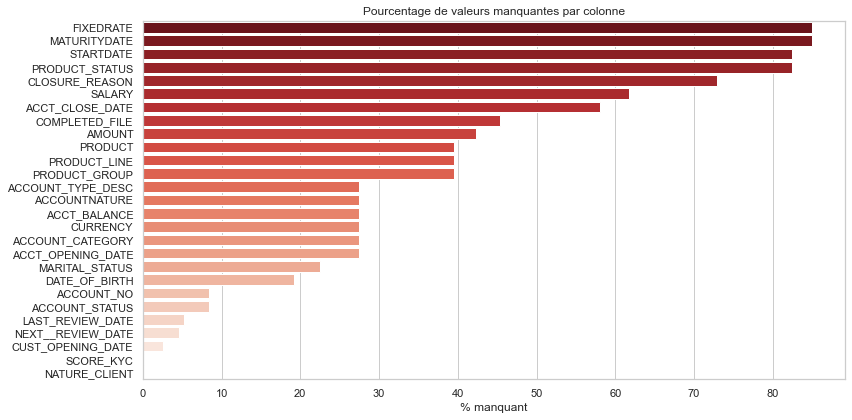

In [5]:
# Analyse des valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
}).sort_values('Pourcentage (%)', ascending=False)

# Afficher seulement les colonnes avec des manquants
missing_df = missing_df[missing_df['Valeurs manquantes'] > 0]
print(f"=== VALEURS MANQUANTES ({len(missing_df)} colonnes concernées) ===")
display(missing_df)

# Visualisation
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_df['Pourcentage (%)'], y=missing_df.index, palette='Reds_r')
plt.title('Pourcentage de valeurs manquantes par colonne')
plt.xlabel('% manquant')
plt.tight_layout()
plt.show()

=== DISTRIBUTION DE ACCOUNT_STATUS ===
Active    262502
Closed    221941
NaN        44440
Name: ACCOUNT_STATUS, dtype: int64

✅ Comptes Actifs   :    306,942  (58.0%)
🚨 Comptes Clôturés :    221,941  (42.0%)
❓ Statut manquant  :     44,440  (8.4%)


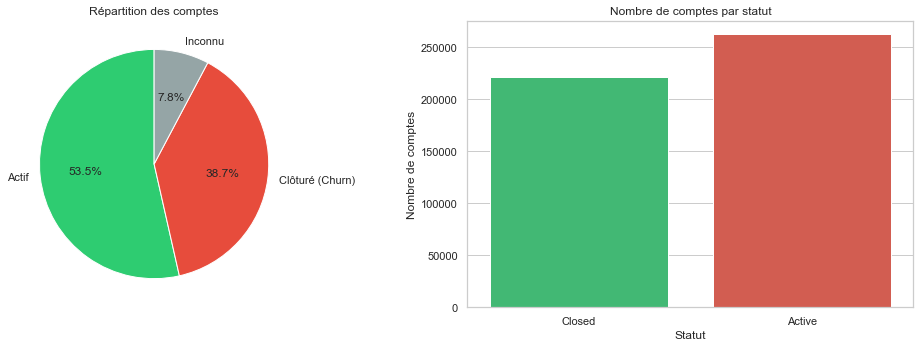

In [6]:
# La variable cible : ACCOUNT_STATUS
print("=== DISTRIBUTION DE ACCOUNT_STATUS ===")
print(df['ACCOUNT_STATUS'].value_counts(dropna=False))
print()

# Définition du churn : Closed = 1, Active = 0
df['CHURN'] = (df['ACCOUNT_STATUS'] == 'Closed').astype(int)

total = len(df)
churned = df['CHURN'].sum()
active = total - churned
missing_status = df['ACCOUNT_STATUS'].isnull().sum()

print(f"✅ Comptes Actifs   : {active:>10,}  ({active/total*100:.1f}%)")
print(f"🚨 Comptes Clôturés : {churned:>10,}  ({churned/total*100:.1f}%)")
print(f"❓ Statut manquant  : {missing_status:>10,}  ({missing_status/total*100:.1f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
labels = ['Actif', 'Clôturé (Churn)', 'Inconnu']
sizes  = [active, churned, missing_status]
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Répartition des comptes')

# Bar chart
sns.countplot(data=df, x='ACCOUNT_STATUS', palette=['#2ecc71','#e74c3c'], ax=axes[1])
axes[1].set_title('Nombre de comptes par statut')
axes[1].set_xlabel('Statut')
axes[1].set_ylabel('Nombre de comptes')

plt.tight_layout()
plt.show()

In [7]:
# Analyse des variables catégorielles importantes
cols_cat = ['NATIONALITY', 'RESIDENCE', 'MARITAL_STATUS', 
            'NATURE_CLIENT', 'SCORE_KYC', 'CURRENCY']

print("=== DISTRIBUTION DES VARIABLES CATÉGORIELLES ===\n")
for col in cols_cat:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).head(8))
    print()

# Analyse des variables numériques
cols_num = ['DATE_OF_BIRTH', 'SALARY', 'ACCT_BALANCE', 'INDUSTRY', 'LOB']
print("=== STATISTIQUES DES VARIABLES NUMÉRIQUES ===")
display(df[cols_num].describe())

=== DISTRIBUTION DES VARIABLES CATÉGORIELLES ===

--- NATIONALITY ---
TN    509824
LY      4751
FR      4572
IT      1410
DZ      1175
US       817
GB       693
EG       666
Name: NATIONALITY, dtype: int64

--- RESIDENCE ---
TN    494836
FR      9571
US      9346
LY      4691
IT      1565
DE       830
GB       819
DZ       703
Name: RESIDENCE, dtype: int64

--- MARITAL_STATUS ---
M      219232
C      175164
NaN    118698
V        9031
D        6758
Name: MARITAL_STATUS, dtype: int64

--- NATURE_CLIENT ---
PPH     374968
PM       98650
PRO      28417
TRPP     25888
CB         424
TRPM       294
TRBQ       148
NaN         78
Name: NATURE_CLIENT, dtype: int64

--- SCORE_KYC ---
LR     342717
H1      67244
MR      61842
H2      38475
H3      17760
NaN       845
Name: SCORE_KYC, dtype: int64

--- CURRENCY ---
TND    357122
NaN    144925
EUR     13174
USD      7942
TDC      4654
CAD       360
CHF       203
GBP       187
Name: CURRENCY, dtype: int64

=== STATISTIQUES DES VARIABLES NUMÉRIQUES 

,DATE_OF_BIRTH,SALARY,ACCT_BALANCE,INDUSTRY,LOB
count,427568.00,202234.00,383958.00,528883.00,528883.00
mean,1976.25,5588.48,4409.02,7983.97,6.06
std,17.29,149836.63,810619.54,2511.47,5.46
min,1190.00,0.00,-43823115.66,111.00,1.00
25%,1964.00,400.00,0.00,9000.00,4.00
50%,1977.00,612.00,2.09,9000.00,4.00
75%,1989.00,1647.00,1087.91,9000.00,4.00
max,2026.00,25000000.00,64141930.15,9998.00,999.00


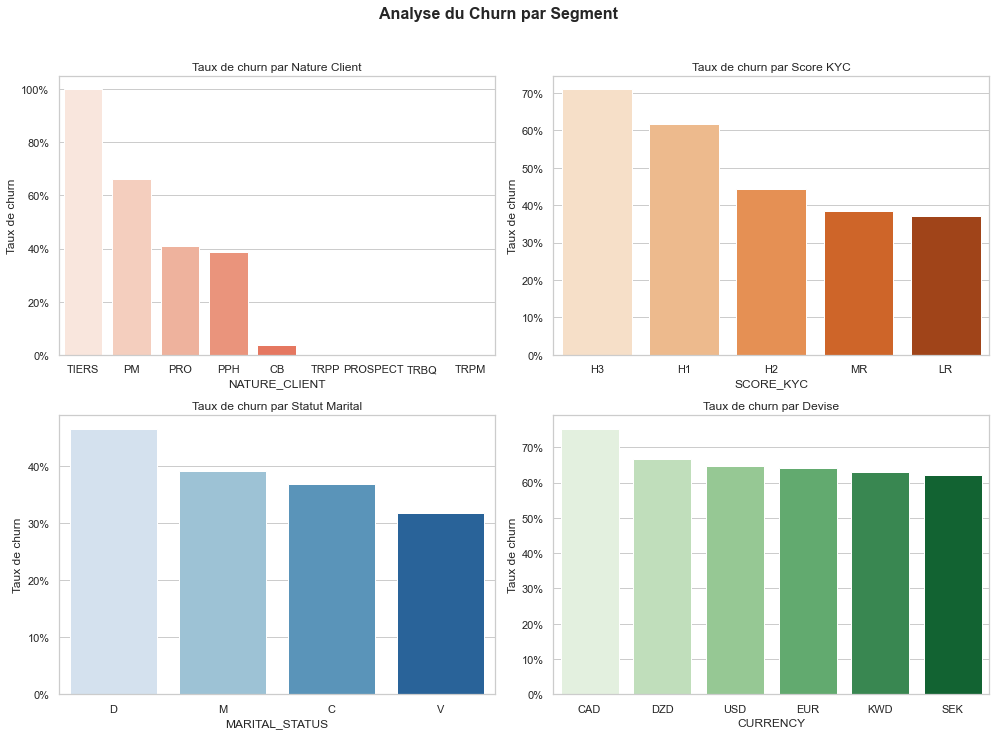

In [8]:
# Churn par NATURE_CLIENT
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Churn par nature client
churn_nature = df.groupby('NATURE_CLIENT')['CHURN'].mean().sort_values(ascending=False)
sns.barplot(x=churn_nature.index, y=churn_nature.values, palette='Reds', ax=axes[0,0])
axes[0,0].set_title('Taux de churn par Nature Client')
axes[0,0].set_ylabel('Taux de churn')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# 2. Churn par SCORE_KYC
churn_kyc = df.groupby('SCORE_KYC')['CHURN'].mean().sort_values(ascending=False)
sns.barplot(x=churn_kyc.index, y=churn_kyc.values, palette='Oranges', ax=axes[0,1])
axes[0,1].set_title('Taux de churn par Score KYC')
axes[0,1].set_ylabel('Taux de churn')
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# 3. Churn par MARITAL_STATUS
churn_marital = df.groupby('MARITAL_STATUS')['CHURN'].mean().sort_values(ascending=False)
sns.barplot(x=churn_marital.index, y=churn_marital.values, palette='Blues', ax=axes[1,0])
axes[1,0].set_title('Taux de churn par Statut Marital')
axes[1,0].set_ylabel('Taux de churn')
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# 4. Churn par CURRENCY
churn_currency = df.groupby('CURRENCY')['CHURN'].mean().sort_values(ascending=False).head(6)
sns.barplot(x=churn_currency.index, y=churn_currency.values, palette='Greens', ax=axes[1,1])
axes[1,1].set_title('Taux de churn par Devise')
axes[1,1].set_ylabel('Taux de churn')
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.suptitle('Analyse du Churn par Segment', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

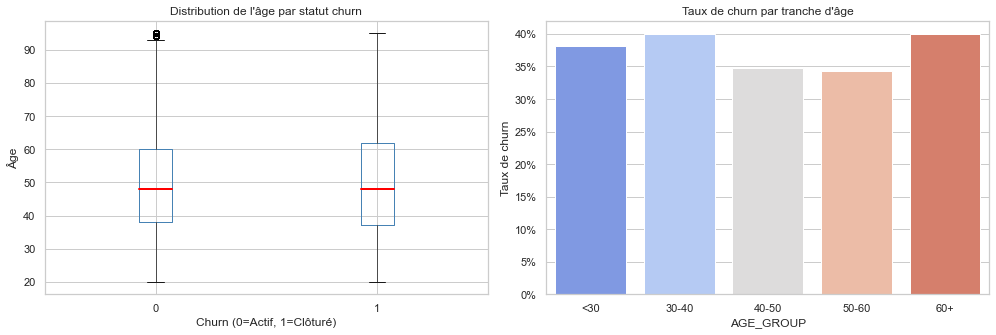

=== CHURN PAR TRANCHE D'ÂGE ===
          Taux churn  Nb clients
AGE_GROUP                       
<30            38.2%       46527
30-40          40.0%       85442
40-50          34.8%       96091
50-60          34.2%       78622
60+            40.0%      107076


In [9]:
# Nettoyage DATE_OF_BIRTH pour l'analyse
df_valid = df[(df['DATE_OF_BIRTH'] >= 1930) & (df['DATE_OF_BIRTH'] <= 2005)].copy()
df_valid['AGE'] = 2025 - df_valid['DATE_OF_BIRTH']
df_valid['AGE_GROUP'] = pd.cut(df_valid['AGE'], 
                                bins=[0, 30, 40, 50, 60, 100],
                                labels=['<30', '30-40', '40-50', '50-60', '60+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution de l'âge par churn
df_valid.boxplot(column='AGE', by='CHURN', ax=axes[0], 
                 boxprops=dict(color='steelblue'),
                 medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Distribution de l\'âge par statut churn')
axes[0].set_xlabel('Churn (0=Actif, 1=Clôturé)')
axes[0].set_ylabel('Âge')
plt.sca(axes[0])
plt.title('Distribution de l\'âge par statut churn')

# 2. Taux de churn par tranche d'âge
churn_age = df_valid.groupby('AGE_GROUP', observed=True)['CHURN'].mean()
sns.barplot(x=churn_age.index, y=churn_age.values, palette='coolwarm', ax=axes[1])
axes[1].set_title('Taux de churn par tranche d\'âge')
axes[1].set_ylabel('Taux de churn')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.suptitle('')
plt.tight_layout()
plt.show()

# Résumé
print("=== CHURN PAR TRANCHE D'ÂGE ===")
print(df_valid.groupby('AGE_GROUP', observed=True)['CHURN'].agg(['mean','count'])
      .rename(columns={'mean':'Taux churn','count':'Nb clients'})
      .assign(**{'Taux churn': lambda x: x['Taux churn'].map('{:.1%}'.format)}))

In [10]:
# ============================================
# RÉSUMÉ DE L'EXPLORATION
# ============================================
print("=" * 55)
print("        RÉSUMÉ DE L'EXPLORATION DES DONNÉES")
print("=" * 55)

print(f"""
📊 DATASET PRINCIPAL
   • Lignes            : 528,883
   • Colonnes          : 34
   • Colonnes utiles   : ~20 (après nettoyage)

🎯 VARIABLE CIBLE (CHURN)
   • Comptes Actifs    : 306,942  (58.0%)
   • Comptes Clôturés  : 221,941  (42.0%)
   • Statut inconnu    :  44,440  ( 8.4%) → à exclure
   • Déséquilibre      : Faible → dataset quasi équilibré ✅

⚠️  PROBLÈMES IDENTIFIÉS
   • DATE_OF_BIRTH     : valeurs aberrantes (1190, 2026) → filtrer
   • SALARY            : outliers extrêmes (max 25M) → à plafonner
   • ACCT_BALANCE      : valeurs négatives normales (découverts)
   • 27 colonnes       : ont des valeurs manquantes

🔑 FEATURES PROMETTEUSES POUR LE ML
   • NATURE_CLIENT     : PM/TIERS churent beaucoup plus
   • SCORE_KYC         : H3 = 70% churn (très prédictif)
   • MARITAL_STATUS    : Divorcés = 45% churn
   • CURRENCY          : Devises étrangères = +65% churn
   • AGE               : Impact modéré (~34-40% selon tranche)

📁 TABLES DE DIMENSIONS
   • 8 tables disponibles pour enrichir les données
   • dim_industry (663 lignes) et dim_closure très utiles
""")

print("=" * 55)
print("✅ EDA terminée — Prêt pour l'ETL !")
print("=" * 55)

        RÉSUMÉ DE L'EXPLORATION DES DONNÉES

📊 DATASET PRINCIPAL
   • Lignes            : 528,883
   • Colonnes          : 34
   • Colonnes utiles   : ~20 (après nettoyage)

🎯 VARIABLE CIBLE (CHURN)
   • Comptes Actifs    : 306,942  (58.0%)
   • Comptes Clôturés  : 221,941  (42.0%)
   • Statut inconnu    :  44,440  ( 8.4%) → à exclure
   • Déséquilibre      : Faible → dataset quasi équilibré ✅

⚠️  PROBLÈMES IDENTIFIÉS
   • DATE_OF_BIRTH     : valeurs aberrantes (1190, 2026) → filtrer
   • SALARY            : outliers extrêmes (max 25M) → à plafonner
   • ACCT_BALANCE      : valeurs négatives normales (découverts)
   • 27 colonnes       : ont des valeurs manquantes

🔑 FEATURES PROMETTEUSES POUR LE ML
   • NATURE_CLIENT     : PM/TIERS churent beaucoup plus
   • SCORE_KYC         : H3 = 70% churn (très prédictif)
   • MARITAL_STATUS    : Divorcés = 45% churn
   • CURRENCY          : Devises étrangères = +65% churn
   • AGE               : Impact modéré (~34-40% selon tranche)

📁 TABLES D

SyntaxError: invalid syntax (<ipython-input-11-7bb4d0768498>, line 1)